# Basic Monte Carlo Algorithms

> Simulation-based algorithms to approximate in expectation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## The common toy example

__Estimate Pi__

Strategy:
- Draw random uniform 2-D points (x,y)
- See if (x,y) lives inside a semi-circle centered around (0,0)
- Study the ratio of points inside the semi-circle vs total points
- This ratio should converge to $\frac{1}{4}\pi$

In [14]:
def plot_points(inside, outside):
  # Plot semicircle boundary
  # Create semicircle curve
  R = 1
  theta = np.linspace(0, np.pi, 200)
  x_curve = R * np.cos(theta)
  y_curve = R * np.sin(theta)

  plt.figure(figsize=(6, 6))
  plt.plot(x_curve, y_curve)

  # Plot points
  plt.scatter(inside[0], inside[1], label='Inside')
  plt.scatter(outside[0], outside[1], label='Outside')

  # Formatting
  plt.gca().set_aspect('equal')
  plt.xlim(0, R)
  plt.ylim(0, R)
  plt.xlabel('x')
  plt.ylabel('y')
  plt.title('Semicircle with Inside (blue) and Outside (red) Points')
  plt.legend()

  plt.show()

Draw $N$ uniformly distributed points in $[0,1]\times [0,1]$.

Calculate their magnitude and if within 1, mark them as inside points.

In [15]:
def draw_points(N):
  inside_x, inside_y = [], []
  outside_x, outside_y = [], []
  for _ in range(N):
    x, y = np.random.uniform(0, 1), np.random.uniform(0, 1)
    if (x**2 + y**2) <= 1:
      inside_x += [x]
      inside_y += [y]
    else:
      outside_x +=[x]
      outside_y += [y]

  return [inside_x, inside_y], [outside_x, outside_y]

As long as $x^2 + y^2 \leq 1$, the randomly sampled point can be counted as an inside point. Since a quarter circle has area $\frac{1}{4}\pi r^2$, where $r=1$, the points drawn can approximate the area of the space they make up. The total area of the $[0,1]\times [0,1]$ region is 1, but of the semi-circle it is $\frac{1}{4}\pi r^2$. The counts of points should follow this proportion.

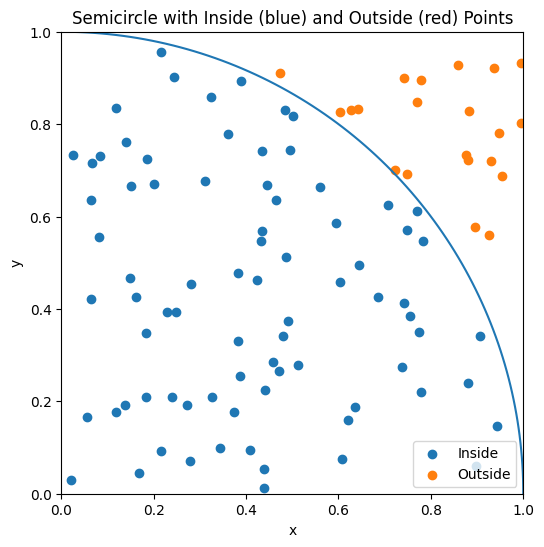

Pi estimate: 3.16


In [23]:
inside, outside = draw_points(100)
plot_points(inside, outside)

inside_count = len(inside[0])
total_count = inside_count + len(outside[0])

print(f"Pi estimate: {4 * inside_count / total_count}")

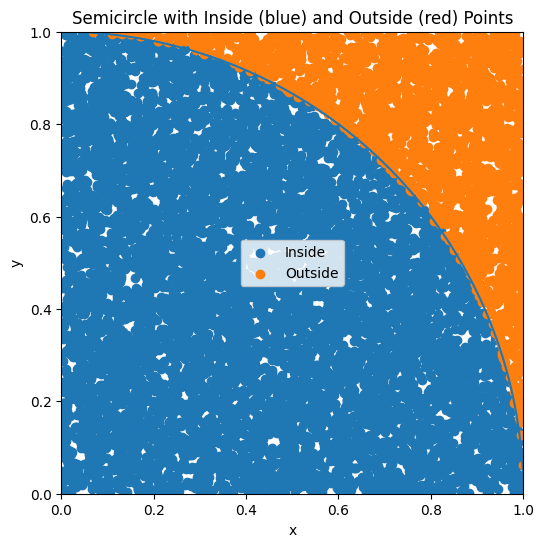

Pi estimate: 3.1244


In [24]:
inside, outside = draw_points(10000)
plot_points(inside, outside)

inside_count = len(inside[0])
total_count = inside_count + len(outside[0])

print(f"Pi estimate: {4 * inside_count / total_count}")

/opt/homebrew/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


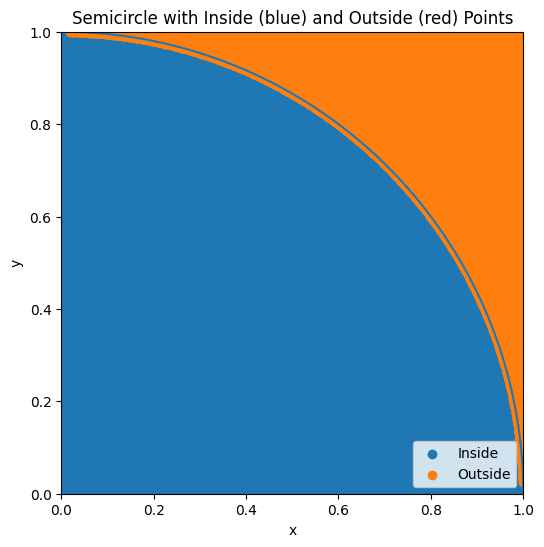

Pi estimate: 3.14102


In [25]:
inside, outside = draw_points(1000000)
plot_points(inside, outside)

inside_count = len(inside[0])
total_count = inside_count + len(outside[0])

print(f"Pi estimate: {4 * inside_count / total_count}")

__As we sample more points, our estimate of pi gets better!__